In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings(action="ignore")

In [2]:
# import dataset
from sklearn.datasets import fetch_california_housing

In [3]:
housing = fetch_california_housing()

In [4]:
dir(housing)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [5]:
housing.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [6]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [7]:
housing.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [8]:
housing.target_names

['MedHouseVal']

In [9]:
# creating the dataframe of dataset
df = pd.DataFrame(housing.data, columns = housing.feature_names)

In [10]:
# df

In [11]:
# df["target"]= housing.target

In [12]:
# df

In [13]:
# df.shape()

---

In [14]:
# other way of creating dataframe

In [15]:
data = fetch_california_housing(as_frame= True)

In [16]:
df = data.frame

In [17]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [18]:
df.shape

(20640, 9)

In [19]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [20]:
# kde = kernanl density estimation

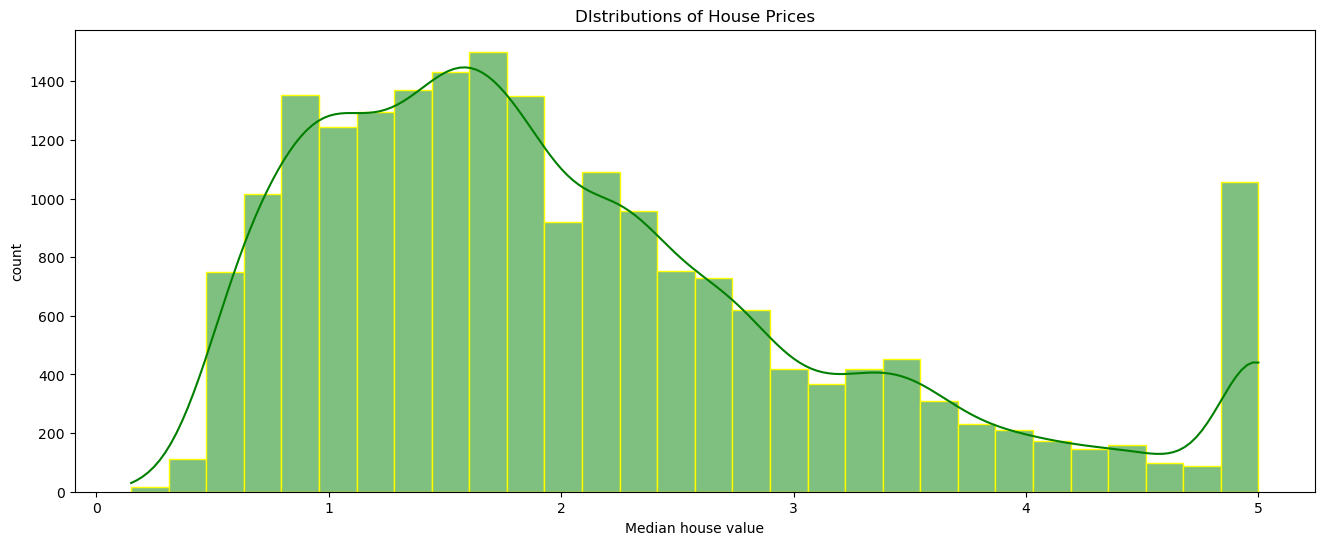

In [21]:
# histplot of distribution of houses
plt.figure(figsize=(16, 6))
sns.histplot(df.MedHouseVal, bins= 30, kde = True, color = "green", edgecolor = "yellow")
plt.title("DIstributions of House Prices")
plt.xlabel("Median house value")
plt.ylabel("count")
plt.show()

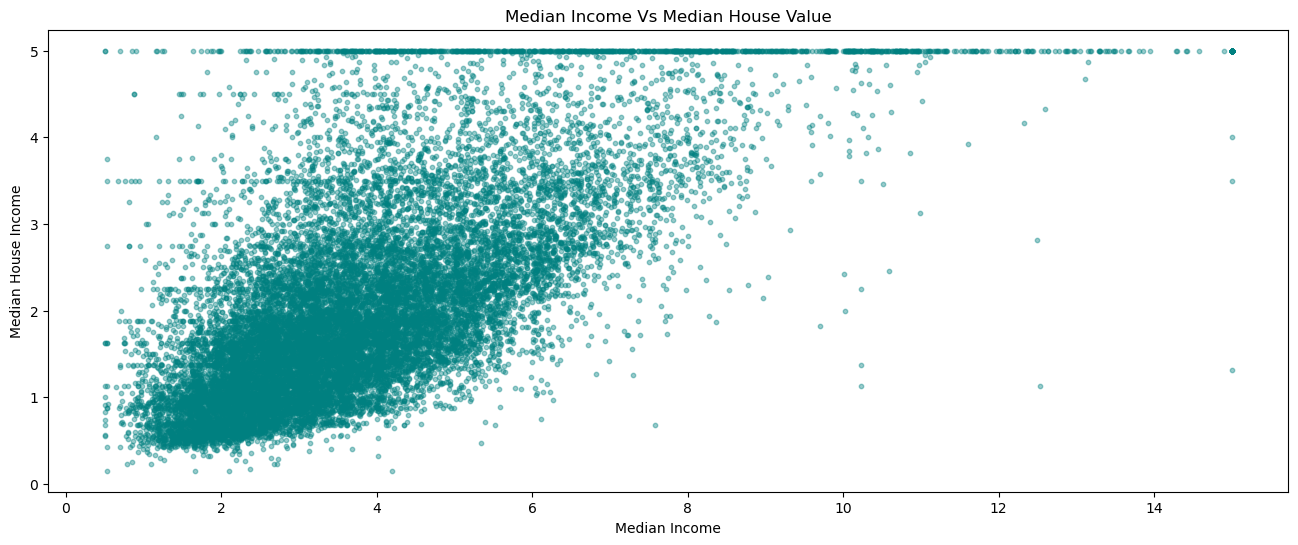

In [22]:
# Scatter plot between the median of house valuse and income
plt.figure(figsize=(16, 6))
plt.scatter(df.MedInc, df.MedHouseVal, alpha = 0.4, s= 10, color= "teal")
plt.title("Median Income Vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Income")
plt.show()

In [23]:
df[:5]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [24]:
# drop the target & split data into x and y
x = df.drop("MedHouseVal", axis = "columns")

In [25]:
x[:1]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23


In [26]:
y = df.MedHouseVal

In [27]:
y[:1]

0    4.526
Name: MedHouseVal, dtype: float64

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state= 1)

In [30]:
len(x_train)

16512

In [31]:
len(x_test)

4128

In [32]:
x_train.shape , x_test.shape, y_train.shape, y_test.shape

((16512, 8), (4128, 8), (16512,), (4128,))

In [33]:
# scaling the data x by STANDARDSCALER
from sklearn.preprocessing import StandardScaler

In [34]:
scaled = StandardScaler()

In [35]:
x_train_scale = scaled.fit_transform(x_train)

In [36]:
x_train_scale[:2]

array([[-0.36232605,  1.85890297, -0.16877334, -0.16841537, -0.4861138 ,
         0.00190139,  0.97229046, -1.42250942],
       [-0.14102329,  1.06434823, -0.20665523, -0.28098123, -0.40424308,
         0.00945496,  1.08459626, -1.38265919]])

In [37]:
x_test_scale = scaled.transform(x_test)

In [38]:
x_test_scale[:2]

array([[-0.33102858,  0.82598181, -0.35885058, -0.0510288 , -0.28143698,
        -0.11362606, -0.73569355,  0.60487084],
       [-1.0032899 ,  0.66707086, -0.173141  , -0.11985381, -0.25118041,
        -0.04185389,  0.53710549, -0.10247067]])

In [39]:
# LINEAR REGRESSION
from sklearn.linear_model import LinearRegression

In [40]:
lr = LinearRegression()

In [41]:
# fitting the data
lr.fit(x_train_scale, y_train)

LinearRegression()

In [42]:
# predictions
y_pred= lr.predict(x_test_scale)

In [43]:
y_pred

array([2.12567705, 0.93977118, 2.70887192, ..., 2.9460839 , 2.63875476,
       1.46985176])

In [44]:
lr.predict([[5.6431,	52.0,	5.817352,	1.073059,	558.0,	2.547945,	37.85,	-122.25]])	

array([83.12029882])

In [45]:
# regression model evaluation matrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [46]:
r2_lr= round(r2_score(y_test, y_pred), 2)

In [47]:
r2_lr

0.6

In [48]:
mae_lr = round(mean_absolute_error(y_test, y_pred), 2)

In [49]:
mae_lr

0.53

In [50]:
mse_lr= round(mean_squared_error(y_test, y_pred), 2)

In [51]:
mse_lr

0.53

In [52]:
rmse_lr= round(np.sqrt(mean_squared_error(y_test, y_pred)),2)

In [53]:
print(rmse_lr)

0.73


In [54]:
# ploting of the r2 score, mae, mse, rmse

In [55]:
# Importing RIDGE & LASSO Regression Models
from sklearn.linear_model import Ridge, Lasso

In [56]:
# Alpha is a parameter that control how much penalty to add for lossing a deminsion
# Ridge = L2 Regularization
# Lasso = L1 Regularization

In [57]:
Ridge = Ridge(alpha= 0.001)

In [58]:
Ridge

Ridge(alpha=0.001)

In [59]:
Ridge.fit(x_train_scale, y_train)

Ridge(alpha=0.001)

In [60]:
y_pred = Ridge.predict(x_test_scale)

In [61]:
y_pred

array([2.12567697, 0.93977161, 2.70887165, ..., 2.94608346, 2.63875484,
       1.46985223])

In [62]:
# RIDGE  alpha = 0.1
# r2 = 0.6, mae = 0.53, mse = 0.53, rmse = 0.73
# alpha = 0.01
# r2 = 0.6, mae = 0.53, mse = 0.53, rmse = 0.73
# alpha = 0.001
# r2 = 0.6, mae = 0.53, mse = 0.53, rmse = 0.73

In [63]:
r2_score_ridge = round(r2_score(y_test, y_pred),2)

In [64]:
r2_score_ridge

0.6

In [65]:
mae_ridge = round(mean_absolute_error(y_test, y_pred),2)

In [66]:
mae_ridge

0.53

In [67]:
mse_ridge = round(mean_squared_error(y_test, y_pred),2)

In [68]:
mse_ridge

0.53

In [69]:
rmse_redge= round(np.sqrt(mean_squared_error(y_test, y_pred)),2)

In [70]:
rmse_redge

np.float64(0.73)

In [71]:
lasso =Lasso(alpha = 0.001)

In [72]:
lasso 

Lasso(alpha=0.001)

In [73]:
lasso.fit(x_train_scale, y_train)

Lasso(alpha=0.001)

In [74]:
y_pred = lasso.predict(x_test_scale)

In [75]:
y_pred

array([2.12219334, 0.94918985, 2.70146187, ..., 2.93528964, 2.6375271 ,
       1.48128008])

In [76]:
# LASSO alpha= 0.1
# r2 = 0.49, mae = 0.62, mse = 0.66, rmse = 0.81
# alpha = 0.01
# r2 = 0.59, mae = 0.54, mse = 0.53, rmse = 0.73
# alpha = 0.001
# r2 = 0.6, mae = 0.53, mse = 0.53, rmse = 0.73

In [77]:
r2_score_lasso = round(r2_score(y_test, y_pred), 2)

In [78]:
r2_score_lasso

0.6

In [79]:
mae_lasso = round(mean_absolute_error(y_test, y_pred), 2)

In [80]:
mae_lasso

0.53

In [81]:
mse_lasso = round(mean_squared_error(y_test, y_pred), 2)

In [82]:
mse_lasso

0.53

In [83]:
rmse_lasso = round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)

In [84]:
rmse_lasso

np.float64(0.73)

---

In [85]:
corpus = [
    ("what models did you train", "I trained Linear Regression, Ridge Regression and Lasso Regression on the California housing dataset."),
    ("which dataset did you use", "I used the California Housing dataset from sklearn.datasets."),
    ("how to predict price", "To predict, send numerical feature values in the same order as the California dataset or use the predict endpoint in the app."),
    ("how to save models", "Models are saved using joblib.dump. You can load them with joblib.load('path')."),
    ("what features are there", "Features include MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude."),
    ("how to evaluate", "We evaluate using MSE and R2 score. Lower MSE and higher R2 are better."),
    ("hello", "Hello! I am a simple California housing assistant. Ask me about the dataset, models, or prediction instructions."),
    ("thanks", "You are welcome! If you want, try asking how to predict or about evaluation metrics."),
    ("default", "Sorry, I didn't understand. Try asking about the dataset, the models, or how to predict house prices.")
]

In [86]:
import nltk

In [87]:
from nltk.tokenize import word_tokenize

In [88]:
from nltk.stem import PorterStemmer

In [89]:
text = 'I am running studies on housing prices and house'

In [90]:
word = word_tokenize(text)

In [91]:
ps = PorterStemmer()

In [92]:
stem_words = [ps.stem(w) for w in word]

In [93]:
print(stem_words)

['i', 'am', 'run', 'studi', 'on', 'hous', 'price', 'and', 'hous']


In [94]:
from nltk.corpus import stopwords

In [95]:
from nltk.stem import WordNetLemmatizer

In [96]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Pawanpreet
[nltk_data]     Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [97]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Pawanpreet
[nltk_data]     Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [98]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to C:\Users\Pawanpreet
[nltk_data]     Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [99]:
stop_words = set(stopwords.words('english'))

In [100]:
lemmatizer = WordNetLemmatizer()

---

In [101]:
import joblib

In [102]:
joblib.dump(lr, "lr_model.pkl")

['lr_model.pkl']

In [103]:
joblib.dump(Ridge, "Ridge_model.pkl")

['Ridge_model.pkl']

In [104]:
joblib.dump(lasso, "lasso_model.pkl")

['lasso_model.pkl']

In [105]:
joblib.dump(scaled, "scaled.pkl")

['scaled.pkl']

In [106]:
joblib.dump(corpus, "corpus.pkl")

['corpus.pkl']

---